## ASSIGNMENT 8: HR Employee Analytics

## Q8.1: Department Headcount
#### Load HR data and display department-wise employee count.

In [2]:
import pandas as pd
df=pd.read_csv('assignment8_hr_employee_data(in).csv')
df

,EmployeeID,EmployeeName,Department,Designation,Salary,JoiningYear,PerformanceRating,ProjectsCompleted,Location
0,5001,Employee_1,HR,Junior,116465,2017,2.2,12,Bangalore
1,5002,Employee_2,Marketing,Intern,71605,2017,3.7,10,Hyderabad
2,5003,Employee_3,Sales,Junior,44955,2017,4.2,18,Hyderabad
3,5004,Employee_4,Marketing,Lead,74049,2020,4.4,36,Delhi
4,5005,Employee_5,HR,Manager,43917,2022,3.2,39,Mumbai
...,...,...,...,...,...,...,...,...,...
145,5146,Employee_146,Sales,Lead,36476,2019,3.5,22,Bangalore
146,5147,Employee_147,Engineering,Intern,81756,2021,3.2,44,Hyderabad
147,5148,Employee_148,Engineering,Lead,120101,2023,4.7,37,Mumbai
148,5149,Employee_149,HR,Manager,32382,2023,3.8,16,Mumbai


In [3]:
df.head()

,EmployeeID,EmployeeName,Department,Designation,Salary,JoiningYear,PerformanceRating,ProjectsCompleted,Location
0,5001,Employee_1,HR,Junior,116465,2017,2.2,12,Bangalore
1,5002,Employee_2,Marketing,Intern,71605,2017,3.7,10,Hyderabad
2,5003,Employee_3,Sales,Junior,44955,2017,4.2,18,Hyderabad
3,5004,Employee_4,Marketing,Lead,74049,2020,4.4,36,Delhi
4,5005,Employee_5,HR,Manager,43917,2022,3.2,39,Mumbai


In [4]:
df.describe()

,EmployeeID,Salary,JoiningYear,PerformanceRating,ProjectsCompleted
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5075.500000,86782.720000,2019.026667,3.530000,27.900000
std,43.445368,34659.407911,2.419015,0.891176,12.759915
min,5001.000000,30192.000000,2015.000000,2.000000,5.000000
25%,5038.250000,60762.000000,2017.000000,2.700000,17.000000
50%,5075.500000,80375.000000,2019.000000,3.600000,27.000000
75%,5112.750000,119835.000000,2021.000000,4.275000,39.000000
max,5150.000000,149639.000000,2023.000000,5.000000,49.000000


In [14]:
employee_count=df['Department'].value_counts().reset_index()
print("Department-Wise Employee Count:")
employee_count

Department-Wise Employee Count:


,Department,count
0,HR,35
1,Sales,33
2,Engineering,31
3,Finance,28
4,Marketing,23


## Q8.2: Salary Analysis
#### Calculate average salary by department and designation.

In [22]:
avg_salary=df.groupby(['Department','Designation'])['Salary'].mean().round(2)
print("Average Salary by Department and Designation:")
avg_salary.reset_index()

Average Salary by Department and Designation:


,Department,Designation,Salary
0,Engineering,Intern,82160.50
1,Engineering,Junior,74756.00
2,Engineering,Lead,81970.60
3,Engineering,Manager,63623.80
4,Engineering,Senior,78217.17
5,Finance,Intern,66093.00
6,Finance,Junior,95564.20
7,Finance,Lead,100611.25
8,Finance,Manager,91417.86
9,Finance,Senior,98621.00


## Q8.3: Location Analysis
#### Group employees by location and calculate total and average salary

In [23]:
location=df.groupby('Location')['Salary'].agg(['sum','mean']).round(2)
print("Salary Analysis by Location:")
print(location)

Salary Analysis by Location:
               sum      mean
Location                    
Bangalore  2904991  88030.03
Delhi      1938600  84286.96
Hyderabad  2319900  85922.22
Mumbai     2772884  84026.79
Pune       3081033  90618.62


## Q8.4: Pivot Table
#### Create a pivot table showing department vs designation with salary totals

In [25]:
pivot=pd.pivot_table(df,index='Department',
                     columns='Designation',values='Salary',
                     aggfunc='sum')
print("Pivot Table for Department vs Desigination with Salary:")
print(pivot)

Pivot Table for Department vs Desigination with Salary:
Designation  Intern  Junior    Lead  Manager  Senior
Department                                          
Engineering  492963  299024  819706   318119  469303
Finance      330465  477821  402445   639925  690347
HR           666986  708881  647120   475112  583002
Marketing    214105  580365  463332   509560  283517
Sales        371103  690224  680354   767055  436574


## Q8.5: Service Years
#### Add a calculated column for service years (current year - JoiningYear).

In [26]:
df['ServiceYear']=2024-df['JoiningYear']

In [33]:
print("Service Year for Employees:")
print(df[['EmployeeID','EmployeeName','JoiningYear','ServiceYear']])

Service Year for Employees:
     EmployeeID  EmployeeName  JoiningYear  ServiceYear
0          5001    Employee_1         2017            7
1          5002    Employee_2         2017            7
2          5003    Employee_3         2017            7
3          5004    Employee_4         2020            4
4          5005    Employee_5         2022            2
..          ...           ...          ...          ...
145        5146  Employee_146         2019            5
146        5147  Employee_147         2021            3
147        5148  Employee_148         2023            1
148        5149  Employee_149         2023            1
149        5150  Employee_150         2023            1

[150 rows x 4 columns]


## Q8.6: Top Earners
#### Find top 10 employees by salary and display their details.

In [38]:
top_earners=df.nlargest(10,'Salary')

In [40]:
print("Top Salary for 10 Employees:")
print(top_earners[['EmployeeID','EmployeeName','Department','Salary']])

Top Salary for 10 Employees:
     EmployeeID  EmployeeName Department  Salary
67         5068   Employee_68  Marketing  149639
7          5008    Employee_8         HR  149072
115        5116  Employee_116    Finance  148696
99         5100  Employee_100         HR  148592
137        5138  Employee_138    Finance  148094
80         5081   Employee_81         HR  146464
68         5069   Employee_69    Finance  143945
18         5019   Employee_19      Sales  142622
77         5078   Employee_78      Sales  141718
23         5024   Employee_24         HR  140107


## Q8.7: Performance Analysis
#### Identify underperformers (PerformanceRating < 3.0) by department

In [62]:
Filter=df[df['PerformanceRating']<3.0]
underperformers=Filter.groupby('Department')
print("UnderPerformance by Department:")
print(Filter)
print(f"Total UnderPerformers:{len(Filter)}")

UnderPerformance by Department:
     EmployeeID  EmployeeName   Department Designation  Salary  JoiningYear  \
0          5001    Employee_1           HR      Junior  116465         2017   
5          5006    Employee_6    Marketing      Intern  100293         2021   
6          5007    Employee_7           HR      Intern  108581         2018   
10         5011   Employee_11           HR      Junior  100269         2023   
12         5013   Employee_13        Sales      Junior  126671         2022   
13         5014   Employee_14      Finance      Intern  102617         2023   
24         5025   Employee_25  Engineering      Intern  122365         2021   
26         5027   Employee_27      Finance     Manager   99166         2020   
29         5030   Employee_30      Finance      Senior   79298         2017   
30         5031   Employee_31    Marketing      Junior   77221         2019   
33         5034   Employee_34           HR      Junior  132811         2019   
42         5043   Em

## Q8.8: Projects Analysis
#### Create a summary showing projects completed by department

In [58]:
project=df.groupby('Department')['ProjectsCompleted'].agg(['sum','mean','count']).reset_index()

print("Project Summary:")
print(project)

## Q8.9: Export Report
#### Export a comprehensive HR summary to hr_summary_report.csv

In [60]:
hr_summary = df.groupby('Department').agg({
'Salary': ['mean', 'sum', 'min', 'max'],
'PerformanceRating': 'mean',
'ProjectsCompleted': 'sum',
'EmployeeID': 'count'
})

In [61]:
hr_summary.to_csv('hr_summary_report.csv',index=False)

## Q8.10: Visualizations
#### Create visualizations for salary distribution and performance ratings.

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

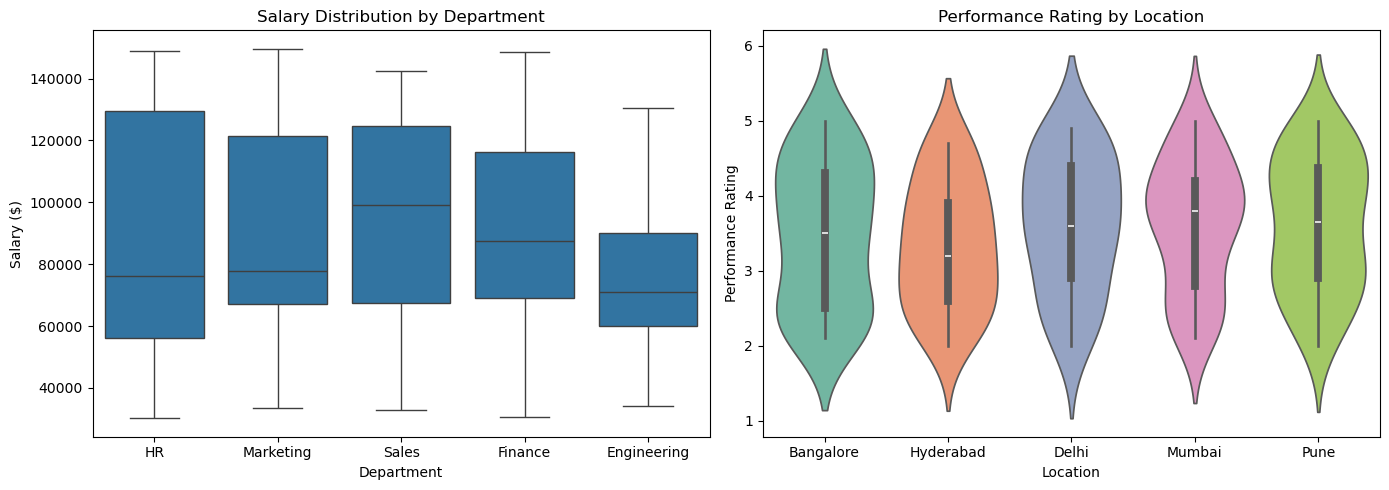

In [72]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Department', y='Salary', ax=ax1)
ax1.set_title('Salary Distribution by Department')
ax1.set_xlabel('Department')
ax1.set_ylabel('Salary ($)')

sns.violinplot(data=df, x='Location', y='PerformanceRating',hue='Location',palette='Set2')
ax2.set_title('Performance Rating by Location')
ax2.set_xlabel('Location')
ax2.set_ylabel('Performance Rating')
              
plt.tight_layout()
plt.show()